In [1]:
import os
import numpy as np
import tensorflow as tf
import cv2 as cv
from tqdm import tqdm
import matplotlib.pyplot as plt
from keras.applications.vgg16 import preprocess_input
import tensorflow.keras.layers as tfl
from sklearn import metrics

In [2]:
def loadData(dir_path):
    X = []
    y = []
    labels = dict()
    i = 0
    for path in tqdm(sorted(os.listdir(dir_path))): #traverse through directories under Train/Val/Test
        if not path.startswith('.'):
            labels[i] = path
            for file in os.listdir(dir_path+'\\'+path):
                if not file.startswith('.'):
                    img = cv.imread(dir_path+'\\'+path+'\\'+file)
                    X.append(img)
                    y.append(i)
            i=i+1
    X = np.array(X,dtype='object')
    y = np.array(y)
    print(f'{len(X)} images loaded from {dir_path} directory.')
    return X,y,labels


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 11.96it/s]


559 images loaded from C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\TRAIN directory.


100%|██████████| 2/2 [00:00<00:00, 67.01it/s]


64 images loaded from C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\VAL directory.


100%|██████████| 2/2 [00:00<00:00, 68.67it/s]

65 images loaded from C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\TEST directory.


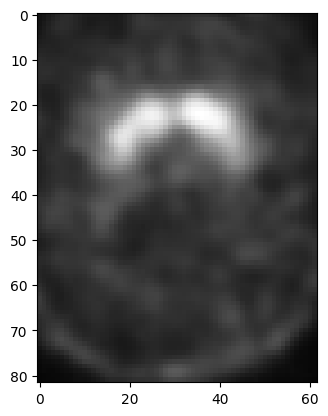

In [3]:
X_train, y_train, labels = loadData(r'C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\TRAIN')
X_val, y_val, _ = loadData(r'C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\VAL')
X_test, y_test, _ = loadData(r'C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\TEST')
IMG_SIZE = (224,224)
plt.imshow(X_train[0])
plt.show()

In [4]:
def preprocess_imgs(set, img_size):
    set_new = []
    for img in set:
        img = cv.resize(img, dsize=img_size, interpolation=cv.INTER_CUBIC)
        set_new.append(preprocess_input(img))
    return np.array(set_new)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


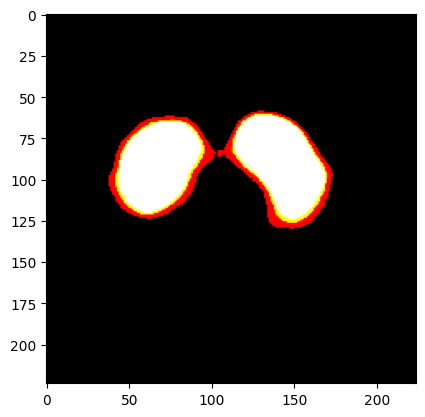

In [5]:
X_train_fin = preprocess_imgs(set=X_train,img_size=IMG_SIZE)
X_val_fin = preprocess_imgs(set=X_val,img_size=IMG_SIZE)
X_test_fin = preprocess_imgs(set=X_test,img_size=IMG_SIZE)
plt.imshow(X_test_fin[0])
plt.show()

In [6]:
from keras.applications.vgg19 import VGG19
from keras.layers import Flatten, Dense, Dropout
from keras.models import Model

vgg = VGG19(
    weights=None,
    include_top=False, 
    input_shape=IMG_SIZE + (3,)
)

model = tf.keras.Sequential()
model.add(vgg)
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))


In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 7, 7, 512)         20024384  
                                                                 
 dropout (Dropout)           (None, 7, 7, 512)         0         
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dropout_1 (Dropout)         (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 1)                 25089     
                                                                 
Total params: 20,049,473
Trainable params: 20,049,473
Non-trainable params: 0
_________________________________________________________________


In [8]:
def plot_roc_curve(true_y, y_prob):

    fpr, tpr, thresholds = metrics.roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.title('ROC')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

In [9]:
model.compile(optimizer='nadam',loss='binary_crossentropy',metrics='accuracy')
mcp = tf.keras.callbacks.ModelCheckpoint(r'C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\Checkpoints\vgg19', monitor="val_accuracy", save_best_only=True, save_weights_only=False)
history = model.fit(X_train_fin,y_train,validation_data=(X_val_fin,y_val),epochs=30,batch_size=32, callbacks=[mcp])

Epoch 1/30
18/18 [==============================] - ETA: 0s - loss: 1.6587 - accuracy: 0.6834 

INFO:tensorflow:Assets written to: C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\Checkpoints\vgg19\assets


INFO:tensorflow:Assets written to: C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\Checkpoints\vgg19\assets


18/18 [==============================] - 191s 10s/step - loss: 1.6587 - accuracy: 0.6834 - val_loss: 0.6337 - val_accuracy: 0.6719
Epoch 2/30
18/18 [==============================] - 186s 10s/step - loss: 0.6266 - accuracy: 0.6959 - val_loss: 0.6328 - val_accuracy: 0.6719
Epoch 3/30
18/18 [==============================] - 186s 10s/step - loss: 0.6167 - accuracy: 0.6959 - val_loss: 0.6271 - val_accuracy: 0.6719
Epoch 4/30
18/18 [==============================] - 186s 10s/step - loss: 0.7248 - accuracy: 0.6923 - val_loss: 0.6516 - val_accuracy: 0.6719
Epoch 5/30
18/18 [==============================] - ETA: 0s - loss: 0.6279 - accuracy: 0.6959 

INFO:tensorflow:Assets written to: C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\Checkpoints\vgg19\assets


INFO:tensorflow:Assets written to: C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\Checkpoints\vgg19\assets


18/18 [==============================] - 189s 10s/step - loss: 0.6279 - accuracy: 0.6959 - val_loss: 0.6399 - val_accuracy: 0.7812
Epoch 6/30
18/18 [==============================] - 184s 10s/step - loss: 0.6148 - accuracy: 0.7066 - val_loss: 0.6328 - val_accuracy: 0.6719
Epoch 7/30
18/18 [==============================] - 185s 10s/step - loss: 0.6164 - accuracy: 0.6977 - val_loss: 0.6328 - val_accuracy: 0.6719
Epoch 8/30
18/18 [==============================] - 186s 10s/step - loss: 0.6200 - accuracy: 0.6959 - val_loss: 0.6336 - val_accuracy: 0.6719
Epoch 9/30
18/18 [==============================] - 185s 10s/step - loss: 0.6149 - accuracy: 0.6959 - val_loss: 0.6340 - val_accuracy: 0.6719
Epoch 10/30
18/18 [==============================] - 185s 10s/step - loss: 0.8683 - accuracy: 0.6673 - val_loss: 0.6329 - val_accuracy: 0.6719
Epoch 11/30
18/18 [==============================] - 185s 10s/step - loss: 0.6847 - accuracy: 0.6959 - val_loss: 0.6329 - val_accuracy: 0.6719
Epoch 12/30
18/

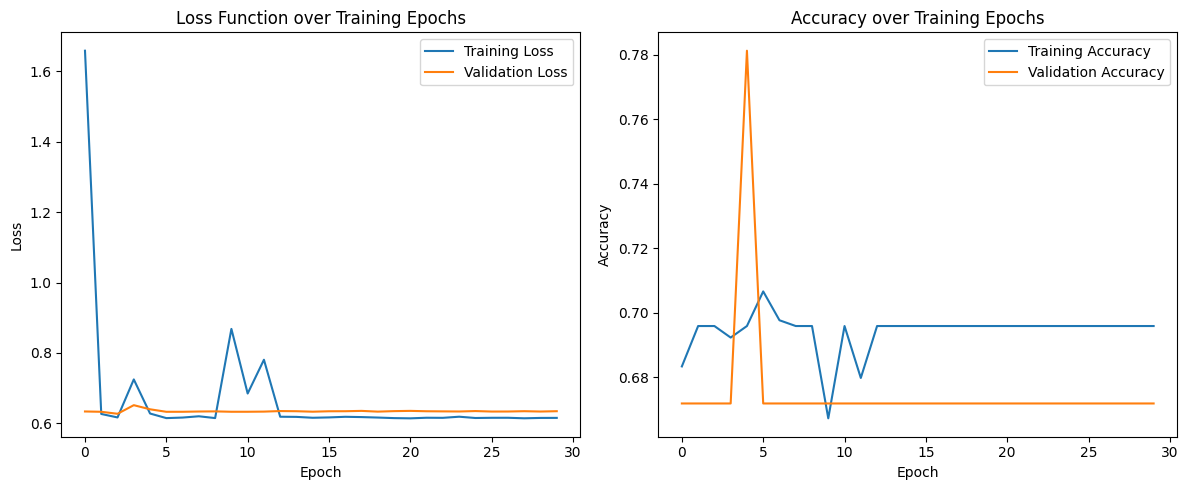

In [10]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plot the loss function graph
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss Function over Training Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Training Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
model.load_weights('../Checkpoints/vgg19')

model.evaluate(X_val_fin,y_val)

2/2 [==============================] - 5s 3s/step - loss: 0.6399 - accuracy: 0.7812


[0.6398863196372986, 0.78125]

In [12]:
model.evaluate(X_test_fin,y_test)

3/3 [==============================] - 6s 1s/step - loss: 0.6327 - accuracy: 0.8000


[0.632714033126831, 0.800000011920929]

In [13]:
yhat_val = model.predict(X_val_fin)
yhat_val_fin = [1 if x>=0.5 else 0 for x in yhat_val]
yhat_test = model.predict(X_test_fin)
yhat_test_fin = [1 if x>=0.5 else 0 for x in yhat_test]


3/3 [==============================] - 6s 1s/step


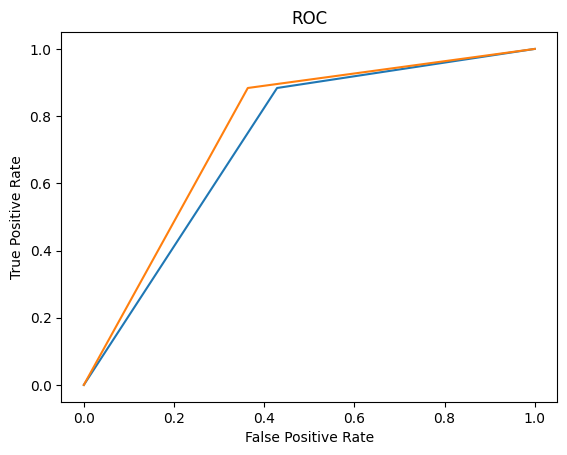

In [14]:
plot_roc_curve(y_val,yhat_val_fin)
plot_roc_curve(y_test,yhat_test_fin)

F1 measure: 0.8444444444444444
ROC AUC: 0.7275747508305648


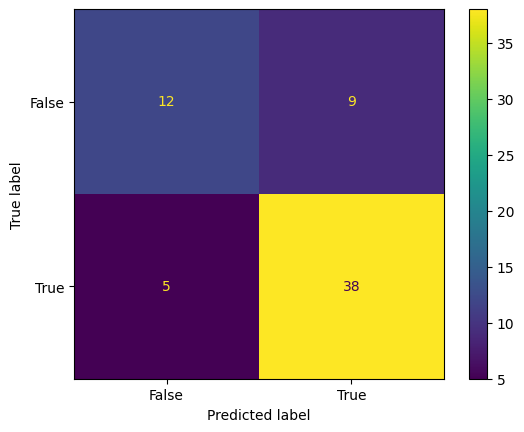

In [15]:
confusion_matrix_val = metrics.confusion_matrix(y_val,yhat_val_fin)
cmv = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_val, display_labels = [False, True])
# plot_roc_curve(y_val,yhat_val_fin)
print(f'F1 measure: {metrics.f1_score(y_val,yhat_val_fin)}\nROC AUC: {metrics.roc_auc_score(y_val,yhat_val_fin)}')
cmv.plot()
plt.show()

F1 measure: 0.853932584269663
ROC AUC: 0.7600422832980973


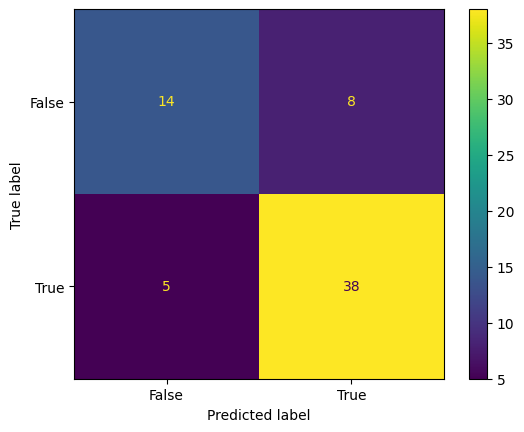

In [16]:
confusion_matrix_test = metrics.confusion_matrix(y_test,yhat_test_fin)
cmt = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_test, display_labels = [False, True])
# plot_roc_curve(y_test,yhat_test_fin)
print(f'F1 measure: {metrics.f1_score(y_test,yhat_test_fin)}\nROC AUC: {metrics.roc_auc_score(y_test,yhat_test_fin)}')
cmt.plot()
plt.show()

In [17]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
i = 31
explainer = lime_image.LimeImageExplainer()
img = X_test_fin[i].astype(np.uint8)

c:\Users\sriha\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
explanation = explainer.explain_instance(img,model.predict,top_labels=2, hide_color = 0, num_samples = 250)

  0%|          | 0/250 [00:00<?, ?it/s]

1/1 [==============================] - 1s 1s/step


  4%|▍         | 10/250 [00:01<00:26,  9.12it/s]

1/1 [==============================] - 1s 878ms/step


  8%|▊         | 20/250 [00:02<00:22, 10.03it/s]

...

 92%|█████████▏| 230/250 [00:23<00:01, 10.03it/s]

1/1 [==============================] - 1s 867ms/step


 96%|█████████▌| 240/250 [00:24<00:00, 10.26it/s]

1/1 [==============================] - 1s 866ms/step


100%|██████████| 250/250 [00:25<00:00,  9.96it/s]


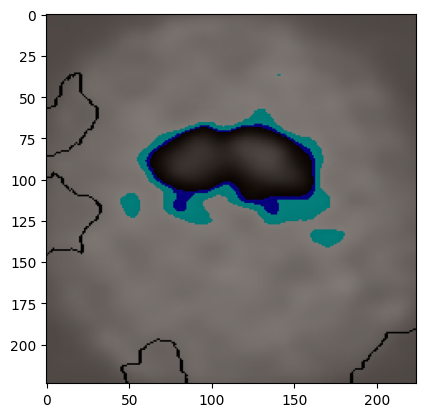

yhat:  1 
True:  1


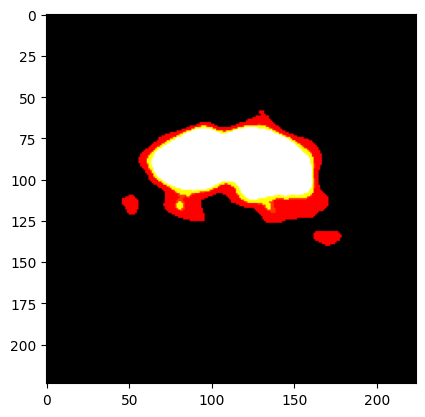

In [20]:
temp, mask = explanation.get_image_and_mask(0,positive_only = True, num_features=10, hide_rest = False)
plt.imshow(mark_boundaries(temp/2 + 0.5,mask).astype(np.uint8))  
plt.show() 
print("yhat: ",yhat_test_fin[i],"\nTrue: ",y_test[i])
plt.imshow(X_test_fin[i])
plt.show()
# def gradcam_heatmap(img, model, last_conv_layer_name, classifier_layer_names):
#     img = np.expand_dims(img, axis=0)
#     last_conv_layer = model.get_layer(last_conv_layer_name)
#     last_conv_layer_model = tf.keras.Model(model.inputs, last_conv_layer.output)

#     classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
#     x = classifier_input

#     for layer_name in classifier_layer_names:
#         x = model.get_layer(layer_name)(x)

#     classifier_model = tf.keras.Model(classifier_input, x)

#     with tf.GradientTape() as tape:
#         last_conv_layer_output = last_conv_layer_model(img)
#         tape.watch(last_conv_layer_output)

#         preds = classifier_model(last_conv_layer_output)
#         # Reshape the preds tensor to match the shape of top_class_channel
#         preds = tf.reshape(preds, (-1, preds.shape[-1]))

#         top_pred_index = tf.argmax(preds[0])
#         top_class_channel = preds[:, top_pred_index]

#         grads = tape.gradient(top_class_channel, last_conv_layer_output)

#         pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

#         last_conv_layer_output = last_conv_layer_output.numpy()[0]
#         pooled_grads = pooled_grads.numpy()

#         for i in range(pooled_grads.shape[-1]):
#             last_conv_layer_output[:, :, i] *= pooled_grads[i]

#         heatmap = np.mean(last_conv_layer_output, axis=-1)
#         heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

#     return heatmap

# import matplotlib as mpl

# heatmap = gradcam_heatmap(img, model, last_conv_layer_name, classifier_layer_names)
# heatmap = np.uint8(heatmap*255)
# jet = mpl.colormaps.get_cmap("jet")
# jet_colours = jet(np.arange(256))[:,:3]
# jet_heatmap = jet_colours[heatmap]

# jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
# jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
# jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

# superimposed_img = (jet_heatmap + img)
# superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
# plt.imshow(superimposed_img)
# plt.show()